**Q1: Data Preprocessing**

You have been provided with a CSV file "Cars93.csv." The given dataset is related to cars and contains 26 columns. In the given dataset, “Price” is the target variable (i.e., the output). The marks distribution according to the tasks are as follows:
1. Assign a type to each of the following features (a) Model, (b) Type, (c) Max. Price and (d) Airbags from the following: ordinal/nominal/ratio/interval scale.
2. Write a function to handle the missing values in the dataset (e.g., any NA, NaN values).
3. Write a function to reduce noise (any error in the feature) in individual attributes.
4. Write a function to encode all the categorical features in the dataset according to the
type of variable jointly.
5. Write a function to normalize / scale the features either individually or jointly.
6. Write a function to create a random split of the data into train, validation and test sets in
the ratio of [70:20:10].



**Question 1.1** Assign a type to each of the following features.

**Solution 1.1:-**

a) **Model** → Nominal

b) **Type** → Nominal

c) **Max. Price** → Ratio

d) **Airbags** → Ordinal

**Question 1.2** Write a function to handle the missing values in the dataset (e.g., any NA, NaN values).



In [18]:
# Solution 1.2

import pandas as pd

def handle_missing_values(df):
    """
    Manages missing data in a DataFrame by removing columns with excessive
    missing values and filling in the gaps for remaining columns.

    Parameters:
    df (pd.DataFrame): Input DataFrame containing data

    Returns:
    pd.DataFrame: DataFrame with missing values managed
    """
    # Create a DataFrame copy to avoid altering the original one
    data_frame_copy = df.copy()

    # Set a limit for the minimum number of non-null values required to keep a column
    threshold_value = 0.5 * len(data_frame_copy)

    # Remove columns that have more than 50% missing values
    data_frame_copy = data_frame_copy.dropna(axis=1, thresh=threshold_value)

    # Address missing values based on the type of data in each column
    for column in data_frame_copy.columns:
        if data_frame_copy[column].dtype == 'object':  # Handle categorical columns
            mode_value = data_frame_copy[column].mode()[0]
            data_frame_copy[column] = data_frame_copy[column].fillna(mode_value)
        else:  # Handle numerical columns
            mean_value = data_frame_copy[column].mean()
            data_frame_copy[column] = data_frame_copy[column].fillna(mean_value)

    return data_frame_copy

# Load the dataset from the specified CSV file path
df = pd.read_csv("/content/drive/MyDrive/Cars93.csv")

# Apply the missing values handling function to the DataFrame
data_frame_cleaned = handle_missing_values(df)

# Print DataFrame information to verify missing values have been addressed
print(data_frame_cleaned)




   Manufacturer    Model     Type  Min.Price  Price  Max.Price  MPG.city  \
0         Acura  Integra    Small       12.9   15.9       18.8        25   
1         Acura   Legend  Midsize       29.2   33.9       38.7        18   
2          Audi       90  Compact       25.9   29.1       32.3        20   
3          Audi      100  Midsize       30.8   37.7       44.6        19   
4           BMW     535i  Midsize       23.7   30.0       36.2        22   
..          ...      ...      ...        ...    ...        ...       ...   
88   Volkswagen  Eurovan      Van       16.6   19.7       22.7        17   
89   Volkswagen   Passat  Compact       17.6   20.0       22.4        21   
90   Volkswagen  Corrado   Sporty       22.9   23.3       23.7        18   
91        Volvo      240  Compact       21.8   22.7       23.5        21   
92        Volvo      850  Midsize       24.8   26.7       28.5        20   

    MPG.highway             AirBags DriveTrain  ... Fuel.tank.capacity  \
0            

**Question 1.3** Write a function to reduce noise (any error in the feature) in individual attributes.

Skewness Values:
 Min.Price             1.163823
Price                 1.508243
Max.Price             2.000906
MPG.city              1.676815
MPG.highway           1.209970
EngineSize            0.845494
Horsepower            0.936308
RPM                  -0.254344
Rev.per.mile          0.276984
Fuel.tank.capacity    0.106394
Passengers            0.061504
Length               -0.088635
Wheelbase             0.111884
Width                 0.259750
Turn.circle          -0.131405
Rear.seat.room        0.077805
Luggage.room          0.239984
Weight               -0.141341
dtype: float64

Summary Statistics:
                     count         mean         std     min     25%     50%  \
Min.Price            93.0    17.125806    8.746029     6.7    10.8    14.7   
Price                93.0    19.509677    9.659430     7.4    12.2    17.7   
Max.Price            93.0    21.898925   11.030457     7.9    14.7    19.6   
MPG.city             93.0    22.365591    5.619812    15.0    18.0    21.0 

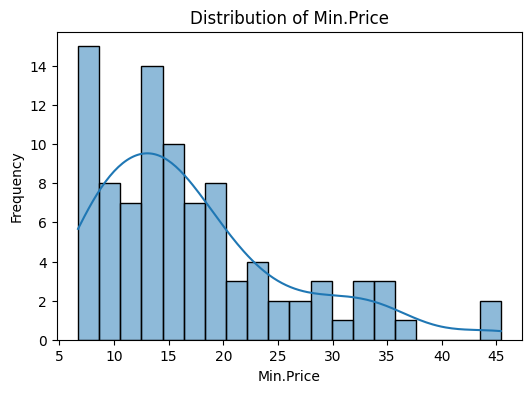

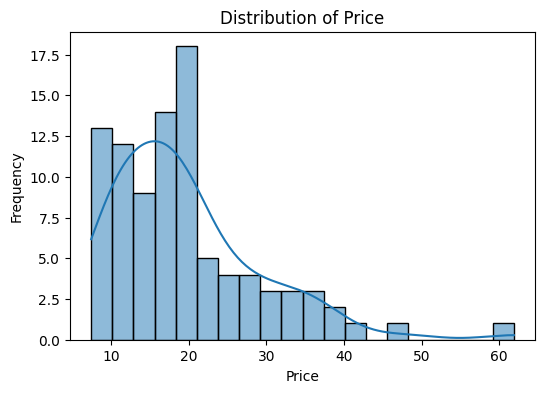

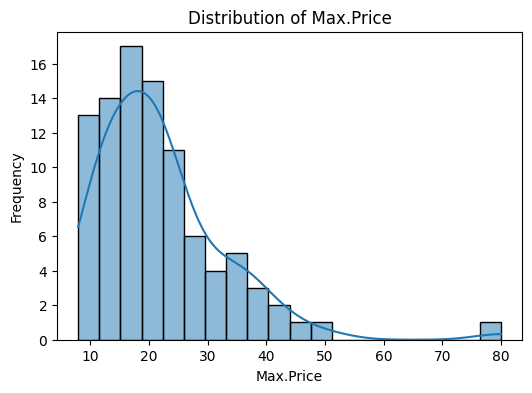

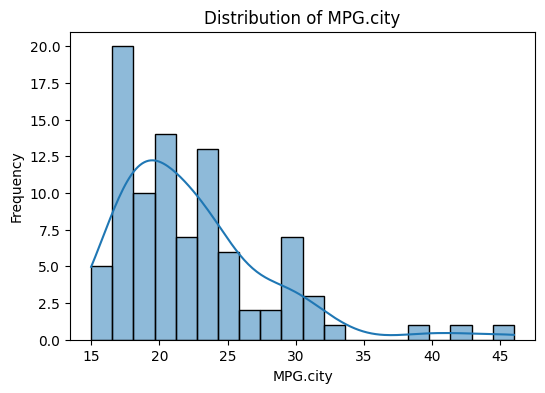

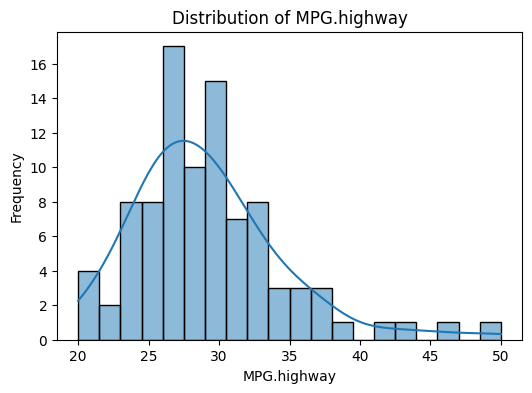

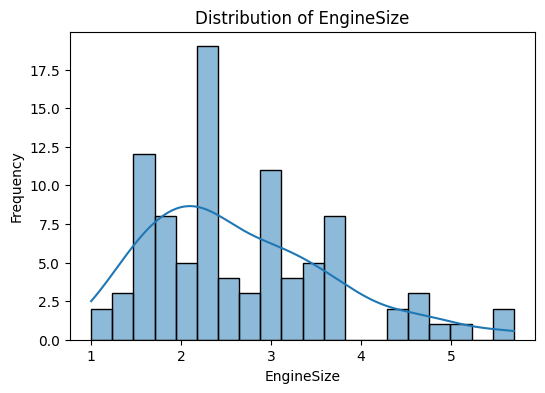

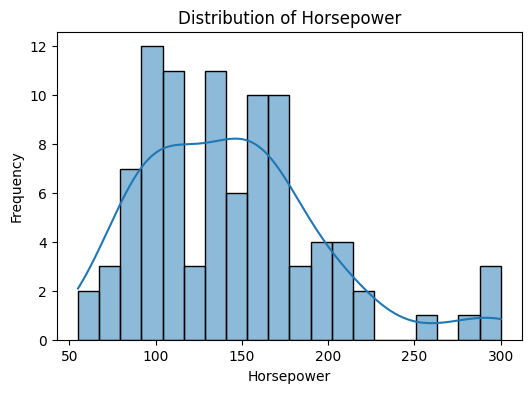

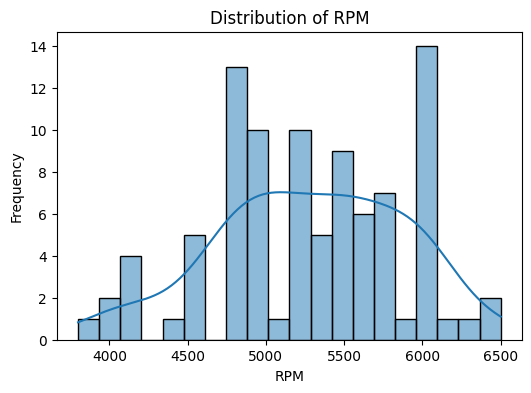

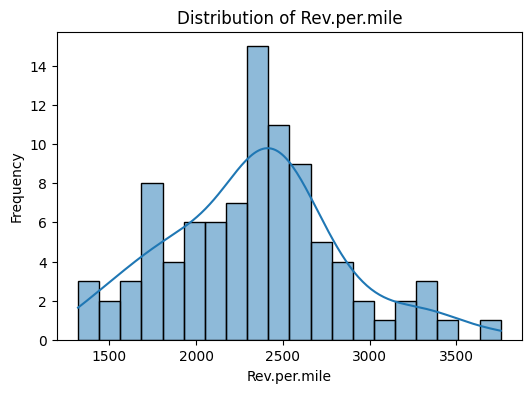

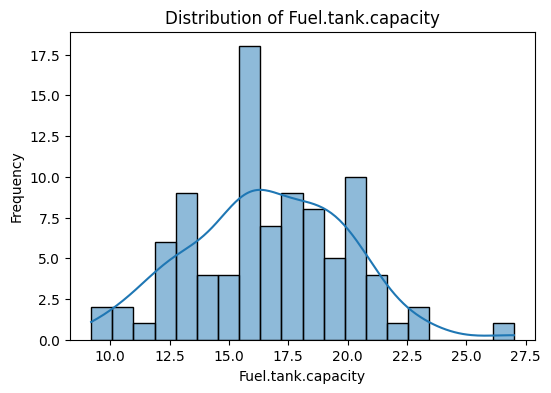

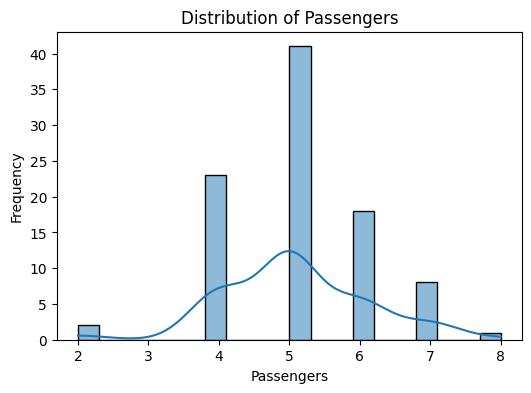

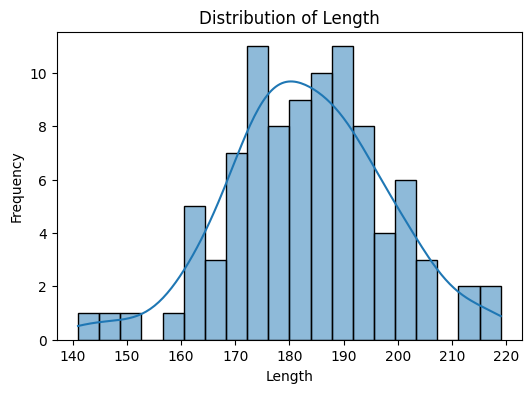

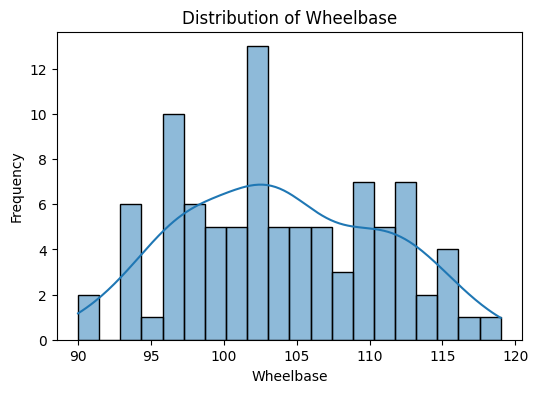

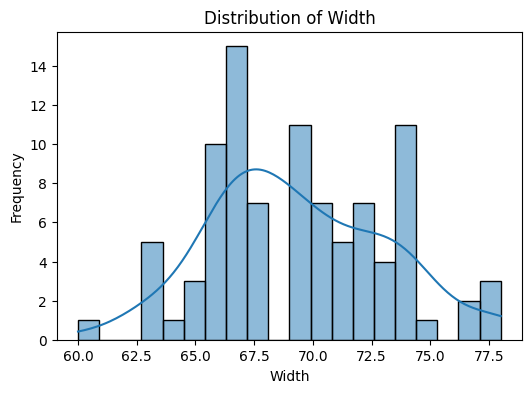

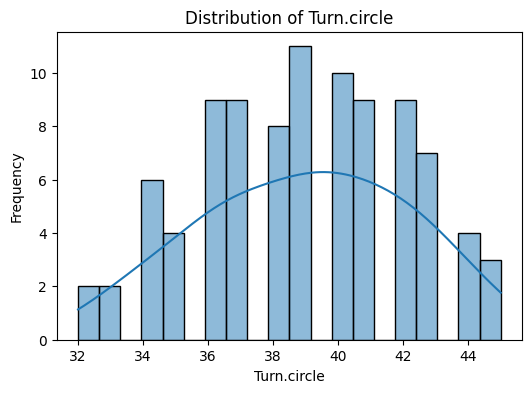

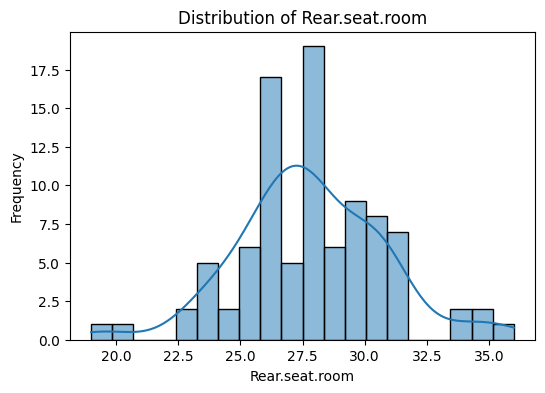

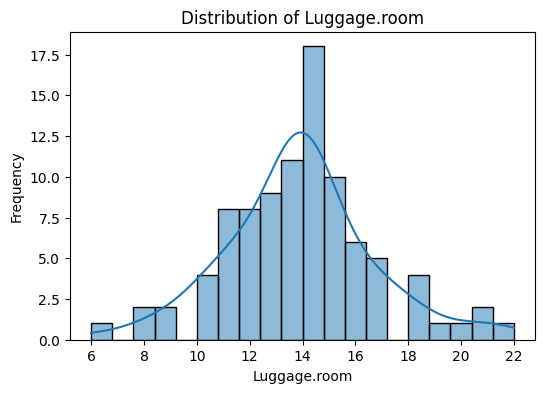

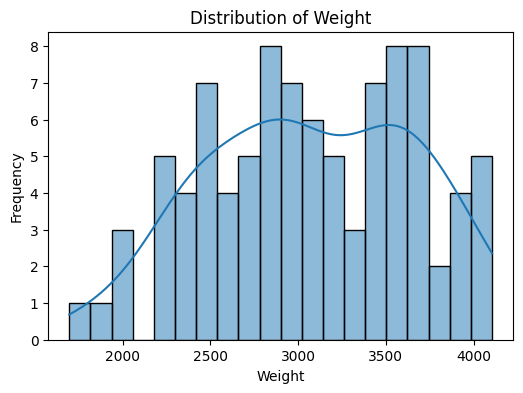

Reduce the noise from data
<class 'pandas.core.frame.DataFrame'>
Index: 63 entries, 0 to 92
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manufacturer        63 non-null     object 
 1   Model               63 non-null     object 
 2   Type                63 non-null     object 
 3   Min.Price           63 non-null     float64
 4   Price               63 non-null     float64
 5   Max.Price           63 non-null     float64
 6   MPG.city            63 non-null     int64  
 7   MPG.highway         63 non-null     int64  
 8   AirBags             63 non-null     object 
 9   DriveTrain          63 non-null     object 
 10  Cylinders           63 non-null     object 
 11  EngineSize          63 non-null     float64
 12  Horsepower          63 non-null     int64  
 13  RPM                 63 non-null     int64  
 14  Rev.per.mile        63 non-null     int64  
 15  Man.trans.avail     63 non-null     o

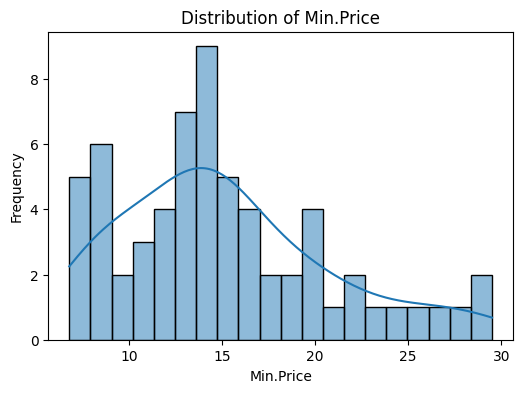

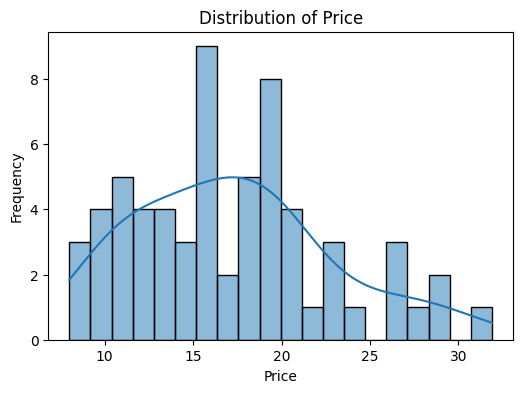

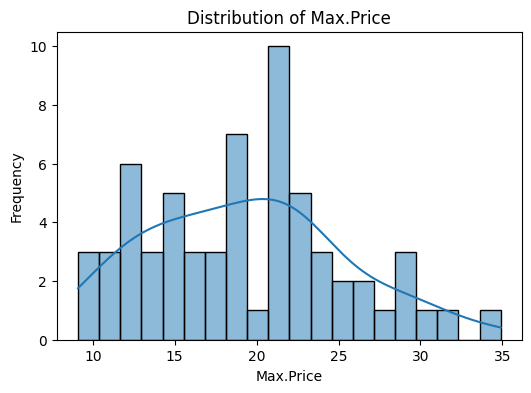

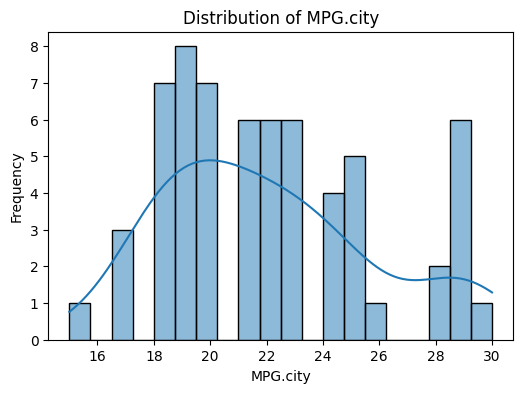

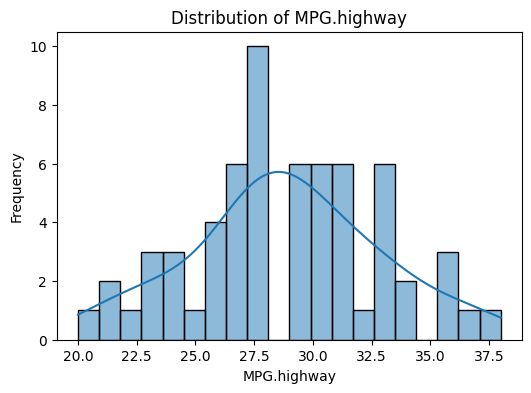

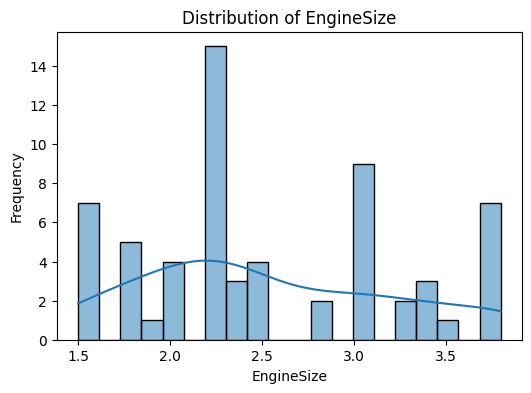

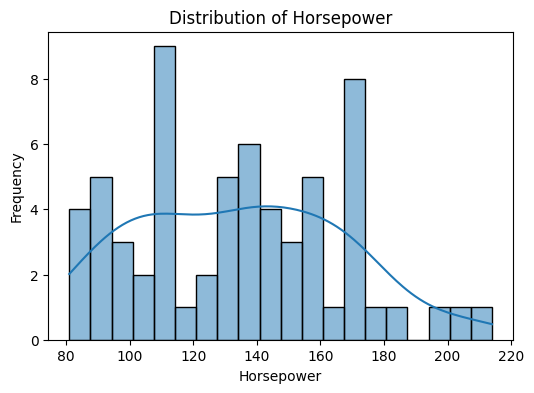

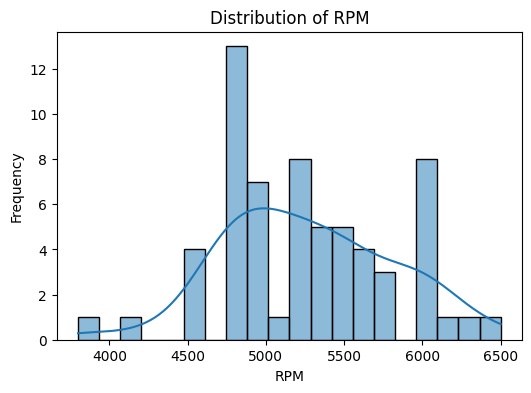

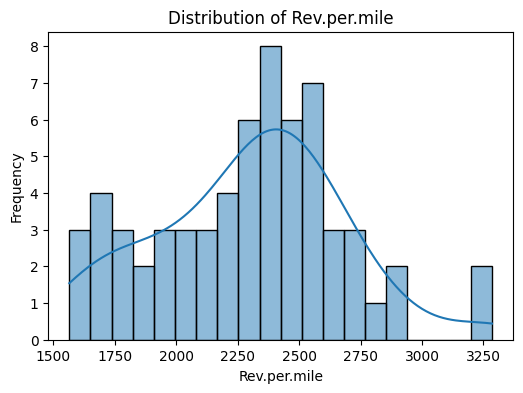

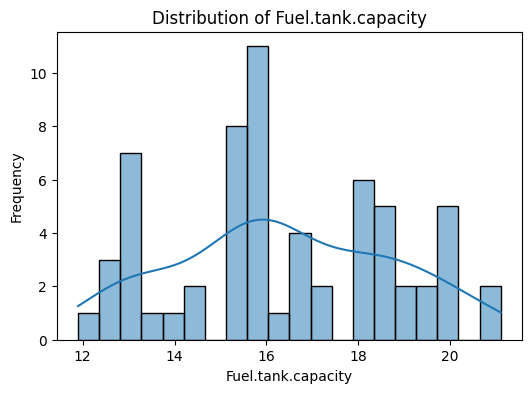

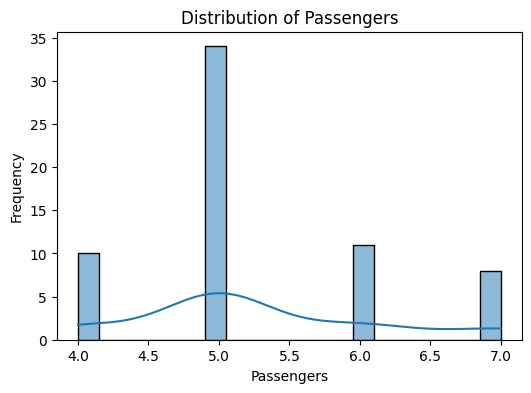

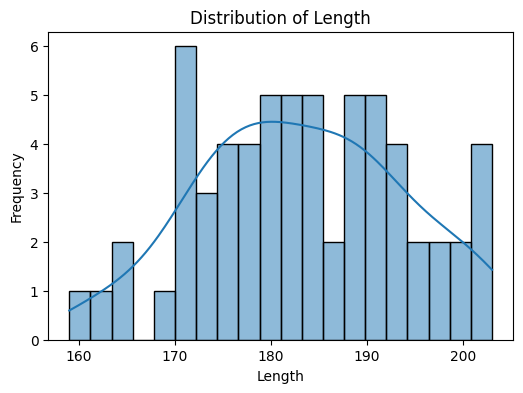

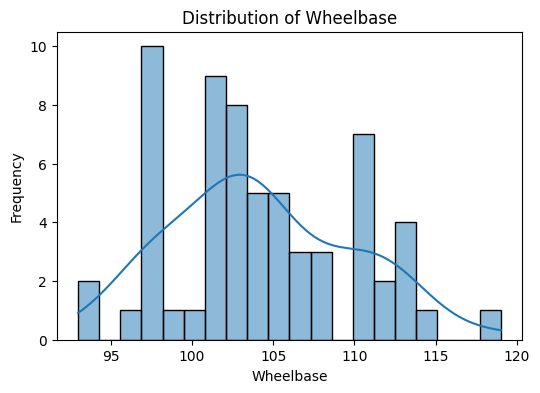

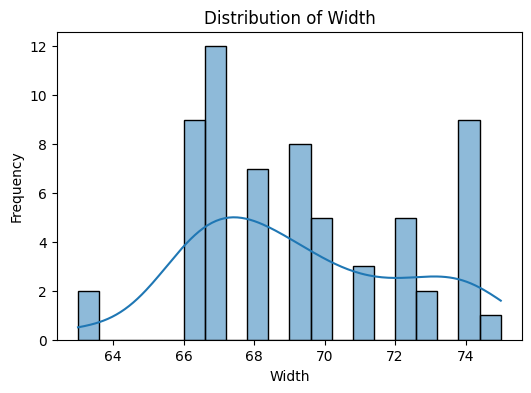

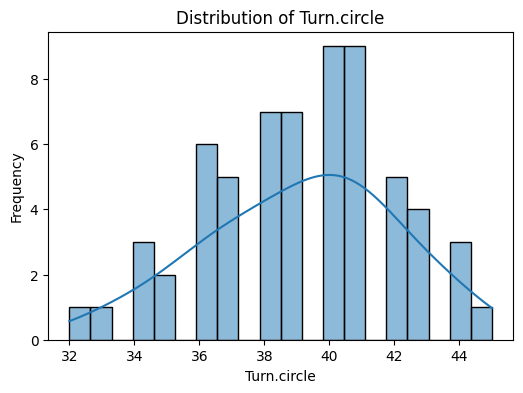

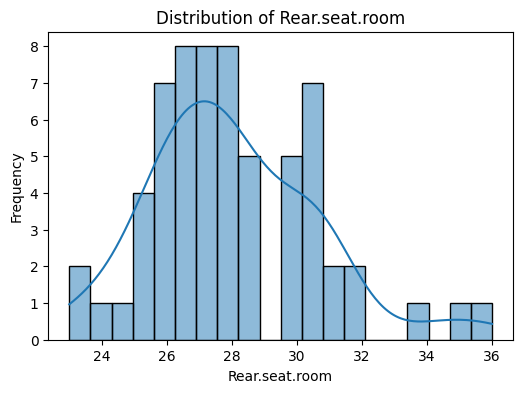

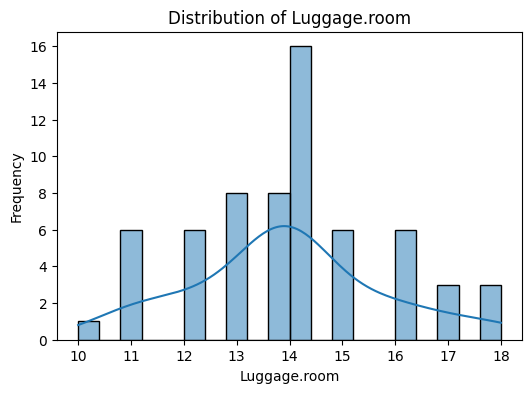

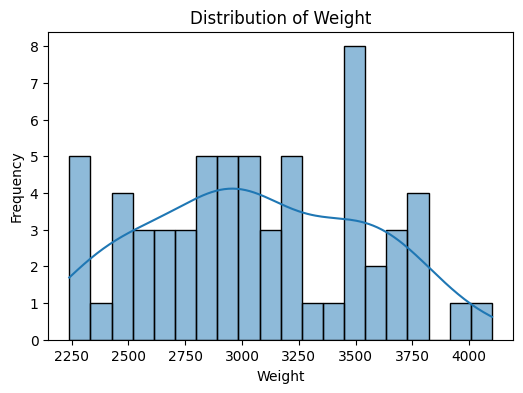

In [19]:
# Solution 1.3
import pandas as pd
import numpy as np
from scipy.stats import skew, shapiro
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns

def check_data_quality(df):
    df_copy = df.copy()

    numeric_cols = df_copy.select_dtypes(include=['float64', 'int64']).columns
    # Check for missing values
    skewness_values = df_copy[numeric_cols].apply(skew, nan_policy='omit')

    # Now, Here we Compute mean and median
    # Transpose for better readability
    summary = df_copy[numeric_cols].describe().T
    summary['median'] = df_copy[numeric_cols].median()

    # Print Skewness Values and Summary Statistics
    print("Skewness Values:\n", skewness_values)
    print("\nSummary Statistics:\n", summary)


def check_reduce_noise(df):
    """
    Minimizes noise in individual attributes by:
    - Filtering outliers in numerical columns using the Interquartile Range (IQR)
    - Standardizing categorical values by trimming spaces and unifying case format
    - Rounding floating-point numbers to maintain consistency

    Args:
        df (pd.DataFrame): Input DataFrame

    Returns:
        pd.DataFrame: Cleaned DataFrame with reduced noise
    """

    # Process numerical columns by removing outliers using the Interquartile Range (IQR)
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]  # Retain values within bounds

    # Clean categorical columns by trimming spaces and converting to lowercase for uniformity
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.strip().str.lower()  # Standardize text formatting

    # Ensure float values are consistent by rounding them to 2 decimal places
    for col in df.select_dtypes(include=[np.float64]).columns:
        df[col] = df[col].round(2)

    return df

def check_skewness(df):
    df_copy = df.copy()
    numeric_cols = df_copy.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
      plt.figure(figsize=(6, 4))
      sns.histplot(df_copy[col], kde=True, bins=20)
      plt.title(f'Distribution of {col}')
      plt.xlabel(col)
      plt.ylabel('Frequency')
      plt.show()

# Load dataset from the specified CSV file
df = pd.read_csv("/content/drive/MyDrive/Cars93.csv")

# Reference from Answer 2:- Apply the missing values handling function to the DataFrame
df = handle_missing_values(df)
# To check the quality of Data
check_data_quality(df)
# To check the Skewness of Data
check_skewness(df)

# Reference from Answer 3:- Apply noise reduction techniques to the DataFrame
print("Reduce the noise from data")
df_cleaned = check_reduce_noise(df)

# Print DataFrame information to verify noise reduction and check data consistency
print(df_cleaned.info())
print("Noise has been reduced")
check_skewness(df_cleaned)


**Question 1.4** Write a function to encode all the categorical features in the dataset according to the
type of variable jointly.

In [21]:
# Solution 1.4

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

def encode_categorical_features(df, ordinal_columns=None, ordinal_mappings=None):
    """
    Encodes categorical features in the dataset.

    - Utilizes One-Hot Encoding for nominal categorical variables.
    - Employs Ordinal Encoding for ordinal categorical variables (if specified).

    Args:
        df (pd.DataFrame): Input DataFrame containing the data
        ordinal_columns (list): List of ordinal columns to encode
        ordinal_mappings (dict): Dictionary with column names as keys and ordered lists as values

    Returns:
        pd.DataFrame: DataFrame with encoded categorical features
    """
    df_encoded = df.copy()  # Create a copy of the DataFrame to avoid modifying the original

    # Identify all columns with categorical data
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    # Detect ordinal columns and their corresponding category order
    ordinal_columns = list(ordinal_mappings.keys()) if ordinal_mappings else []

    # Apply Ordinal Encoding to specified ordinal columns
    if ordinal_columns and ordinal_mappings:
        for col in ordinal_columns:
            if col in df_encoded.columns:
                encoder = OrdinalEncoder(categories=[ordinal_mappings[col]])
                df_encoded[col] = encoder.fit_transform(df_encoded[[col]])

    # Apply One-Hot Encoding to the remaining categorical columns (nominal variables)
    nominal_columns = [col for col in categorical_cols if col not in ordinal_columns]
    df_encoded = pd.get_dummies(df_encoded, columns=nominal_columns, drop_first=True)  # Avoid dummy variable trap

    return df_encoded


# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Cars93.csv")

# Reference from Answer 2: Handle missing values
df_cleaned = handle_missing_values(df)

# Reference from Answer 3: Reduce noise in the data
df_no_noise = check_reduce_noise(df_cleaned)

# Define ordinal columns and their category order
ordinal_cols = ["Airbags"]  # Example of an ordinal variable
ordinal_mapping = {
    "Airbags": ["None", "Driver only", "Driver & Passenger"]
}

# Encode categorical features in the DataFrame
df_encoded = encode_categorical_features(df_no_noise, ordinal_columns=ordinal_cols, ordinal_mappings=ordinal_mapping)

# Display the encoded dataset
print(df_encoded)


    Min.Price  Price  Max.Price  MPG.city  MPG.highway  EngineSize  \
0        12.9   15.9       18.8        25           31         1.8   
2        25.9   29.1       32.3        20           26         2.8   
5        14.2   15.7       17.3        22           31         2.2   
6        19.9   20.8       21.7        19           28         3.8   
8        26.3   26.3       26.3        19           27         3.8   
..        ...    ...        ...       ...          ...         ...   
88       16.6   19.7       22.7        17           21         2.5   
89       17.6   20.0       22.4        21           30         2.0   
90       22.9   23.3       23.7        18           25         2.8   
91       21.8   22.7       23.5        21           28         2.3   
92       24.8   26.7       28.5        20           28         2.4   

    Horsepower   RPM  Rev.per.mile  Fuel.tank.capacity  ...  Type_small  \
0          140  6300          2890                13.2  ...        True   
2        

**Question 1.5** Write a function to normalize / scale the features either individually or jointly.

In [22]:
# Solution 1.5

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

def scale_features(df, methods=["standard"], individual=True):
    df = df.copy()  # Avoid modifying the original dataframe

    # Separate categorical and numerical columns
    numeric_cols = df.select_dtypes(include=['number']).columns
    categorical_cols = df.select_dtypes(exclude=['number']).columns

    # Encode categorical columns
    if not categorical_cols.empty:
        le = LabelEncoder()
        for col in categorical_cols:
            df[col] = le.fit_transform(df[col])  # Convert categories to numbers

    # Apply Scaling
    scaled_dfs = {}
    for method in methods:
        if method == "standard":
            scaler = StandardScaler()
        elif method == "minmax":
            scaler = MinMaxScaler()
        else:
            raise ValueError(f"Unsupported scaling method: {method}")

        scaled_dfs[method] = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)

    return tuple(scaled_dfs[m] for m in methods)

# Call the function
df_standard_scaled, df_minmax_scaled = scale_features(df, methods=["standard", "minmax"])


# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Cars93.csv")

# Reference from Answer 2: Handle missing values
df_cleaned = handle_missing_values(df)

# Reference from Answer 3: Reduce noise in the data
df_no_noise = check_reduce_noise(df_cleaned)

# Define ordinal columns and their category order
ordinal_cols = ["Airbags"]  # Example of an ordinal variable
ordinal_mapping = {
    "Airbags": ["None", "Driver only", "Driver & Passenger"]
}

# Encode categorical features in the DataFrame
df_encoded = encode_categorical_features(df_no_noise, ordinal_columns=ordinal_cols, ordinal_mappings=ordinal_mapping)


# Scale numerical features using Standard Scaling (Z-score) and MinMax
df_standard_scaled, df_minmax_scaled = scale_features(df, methods=["standard", "minmax"], individual=False)


# Display the first few rows of the scaled data
print(df_standard_scaled.head())
print(df_minmax_scaled.head())


   Min.Price     Price  Max.Price  MPG.city  MPG.highway  EngineSize  \
0  -0.485787 -0.375720  -0.282465  0.471312     0.360925   -0.841022   
1   1.388017  1.497844   1.531409 -0.781032    -0.770514    0.515869   
2   1.008658  0.998227   0.948052 -0.423219    -0.581941    0.128186   
3   1.571949  1.893374   2.069191 -0.602126    -0.581941    0.128186   
4   0.755752  1.091905   1.303535 -0.065407     0.172352    0.806631   

   Horsepower       RPM  Rev.per.mile  Fuel.tank.capacity  Passengers  \
0   -0.073484  1.717489      1.129530           -1.062184   -0.083243   
1    1.078322  0.369586      0.005661            0.409445   -0.083243   
2    0.540813  0.369586     -0.105713            0.072197   -0.083243   
3    0.540813  0.369586      0.410659            1.359872    0.884457   
4    1.231897  0.706562      0.430909            1.359872   -1.050944   

     Length  Wheelbase     Width  Turn.circle  Rear.seat.room  Luggage.room  \
0 -0.427186  -0.286932 -0.366184    -0.610436    

**Question 1.6** Write a function to create a random split of the data into train, validation and test sets in
the ratio of [70:20:10]

In [35]:
# Solution 1.6

import pandas as pd
from sklearn.model_selection import train_test_split

def split_data(df, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, random_state=42):
    """
    Splits the dataset into training, validation, and test sets.

    Args:
        df (pd.DataFrame): Input DataFrame containing the data to be split
        train_ratio (float): Proportion of the data to be used for the training set
        val_ratio (float): Proportion of the data to be used for the validation set
        test_ratio (float): Proportion of the data to be used for the test set
        random_state (int): Random seed for reproducibility

    Returns:
        tuple: A tuple containing the training, validation, and test sets as DataFrames
    """
    # Ensure that the sum of train_ratio, val_ratio, and test_ratio equals 1
    assert round(train_ratio + val_ratio + test_ratio, 10) == 1, "Ratios must sum to 1"

    # Split the data into the training set and a temporary set (validation + test)
    train_set, temp_set = train_test_split(df, train_size=train_ratio, random_state=random_state, shuffle=True)

    # Adjust the validation and test ratios relative to the temporary set
    temp_ratio = val_ratio / (val_ratio + test_ratio)
    val_set, test_set = train_test_split(temp_set, train_size=temp_ratio, random_state=random_state, shuffle=True)

    return train_set, val_set, test_set

# Load the dataset from the specified CSV file
df = pd.read_csv("/content/drive/MyDrive/Cars93.csv")

# Reference from Answer 2: Handle missing values
df_cleaned = handle_missing_values(df)


# Reference from Answer 3: Reduce noise in the data
df_no_noise = check_reduce_noise(df_cleaned)

# Define ordinal columns and their category order
ordinal_cols = ["Airbags"]  # Example of an ordinal variable
ordinal_mapping = {
    "Airbags": ["None", "Driver only", "Driver & Passenger"]
}

# Reference from Answer 4: Reduce noise in the dataEncode categorical features in the DataFrame
df_encoded = encode_categorical_features(df_no_noise, ordinal_columns=ordinal_cols, ordinal_mappings=ordinal_mapping)


# Reference from Answer 5:- Scale numerical features using Standard Scaling (Z-score) and MinMax Scale
df_standard_scaled, df_minmax_scaled = scale_features(df_cleaned, methods=["standard", "minmax"], individual=False)

# Define the ratios ensuring they sum to 1
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# Split the data into training, validation, and test sets
train_data, val_data, test_data = split_data(df, train_ratio=train_ratio, val_ratio=val_ratio, test_ratio=test_ratio)

# Display the sizes of the resulting datasets
print(f"Train set: {len(train_data)} rows")
print(train_data.info())
print(f"Validation set: {len(val_data)} rows")
print(val_data.info())
print(f"Test set: {len(test_data)} rows")
print(test_data.info())
print(f"Train set: {len(train_data)} rows")
print(f"Validation set: {len(val_data)} rows")
print(f"Test set: {len(test_data)} rows")

Train set: 65 rows
<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 31 to 51
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manufacturer        65 non-null     object 
 1   Model               65 non-null     object 
 2   Type                65 non-null     object 
 3   Min.Price           65 non-null     float64
 4   Price               65 non-null     float64
 5   Max.Price           65 non-null     float64
 6   MPG.city            65 non-null     int64  
 7   MPG.highway         65 non-null     int64  
 8   AirBags             44 non-null     object 
 9   DriveTrain          65 non-null     object 
 10  Cylinders           65 non-null     object 
 11  EngineSize          65 non-null     float64
 12  Horsepower          65 non-null     int64  
 13  RPM                 65 non-null     int64  
 14  Rev.per.mile        65 non-null     int64  
 15  Man.trans.avail     65 non-null     object 


**Question 2a: Linear Regression Task**

Use the “linear_regression_dataset.csv”
Implement the linear regression model to predict the dependency between two variables.
1. Implement linear regression using the inbuilt function “LinearRegression” model in sklearn.
2. Print the coefficient obtained from linear regression and plot a straight line on the scatter plot.
3. Now, implement linear regression without the use of any inbuilt function.
4. Compare the results of 1 and 3 graphically.

**Question 2a.1** Implement linear regression using the inbuilt function “LinearRegression” model in sklearn.*italicised text*

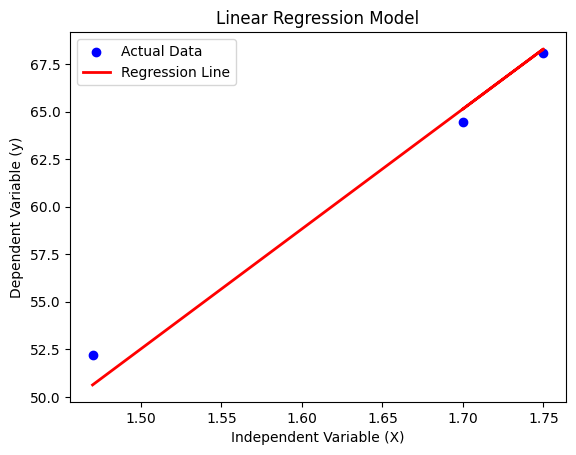

In [36]:
# Solution 2a.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/linear_regression_dataset.csv")

# Assuming the dataset has two columns: 'X' (independent variable) and 'y' (dependent variable)
X = df.iloc[:, :-1].values  # Independent variable
y = df.iloc[:, -1].values   # Dependent variable

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X_train, y_train)

# Make predictions
y_pred = lin_reg.predict(X_test)


# Plot the regression line
plt.scatter(X_test, y_test, color='blue', label="Actual Data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Regression Line")
plt.xlabel("Independent Variable (X)")
plt.ylabel("Dependent Variable (y)")
plt.title("Linear Regression Model")
plt.legend()
plt.show()


**Question 2a.2**  Print the coefficient obtained from linear regression and plot a straight line on the scatter plot.

Intercept: -42.178608958837785
Coefficient: 63.1317191283293
Mean Squared Error: 1.0029930838678223
R² Score: 0.9782994097388882


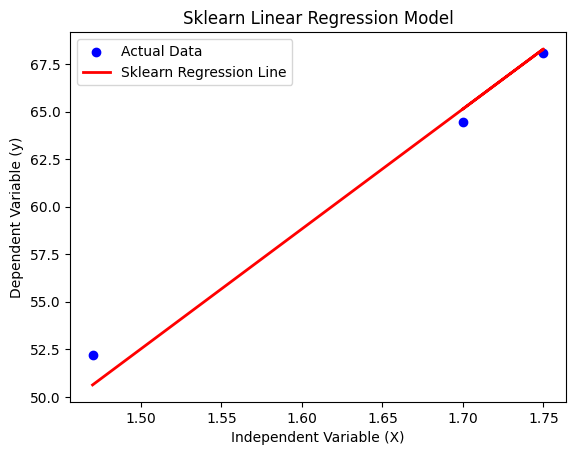

In [37]:
# Solution 2a.2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/linear_regression_dataset.csv")

# Assuming the dataset has two columns: 'X' (independent variable) and 'y' (dependent variable)
X = df.iloc[:, :-1].values  # Independent variable (reshape if needed)
y = df.iloc[:, -1].values   # Dependent variable

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X_train, y_train)

# Make predictions
y_pred = lin_reg.predict(X_test)

# Print model coefficients
print(f"Intercept: {lin_reg.intercept_}")
print(f"Coefficient: {lin_reg.coef_[0]}")  # Assuming single feature
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

# Plot scatter plot and regression line
plt.scatter(X_test, y_test, color='blue', label="Actual Data")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Sklearn Regression Line")
plt.xlabel("Independent Variable (X)")
plt.ylabel("Dependent Variable (y)")
plt.title("Sklearn Linear Regression Model")
plt.legend()
plt.show()


**Question 2a.3** Now, implement linear regression without the use of any inbuilt function.


Intercept (Theta0): -39.06195591884233
Coefficient (Theta1): 61.27218654210937


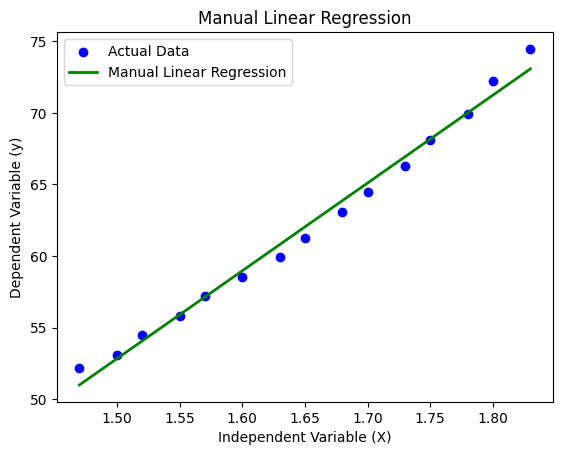

In [38]:
# Solution 2a.3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/linear_regression_dataset.csv")

# Assuming the dataset has two columns: 'X' (independent variable) and 'y' (dependent variable)
X = df.iloc[:, :-1].values  # Independent variable
y = df.iloc[:, -1].values   # Dependent variable

# Add bias term (X0 = 1) for the intercept
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Adding ones column for intercept

# Compute theta using the Normal Equation
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Print model parameters
print(f"Intercept (Theta0): {theta[0]}")
print(f"Coefficient (Theta1): {theta[1]}")  # Assuming single feature

# Predict values
y_pred = X_b.dot(theta)

# Plot scatter plot and regression line
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, y_pred, color='green', linewidth=2, label="Manual Linear Regression")
plt.xlabel("Independent Variable (X)")
plt.ylabel("Dependent Variable (y)")
plt.title("Manual Linear Regression")
plt.legend()
plt.show()


**Question 2a.4** Compare the results of 1 and 3 graphically.





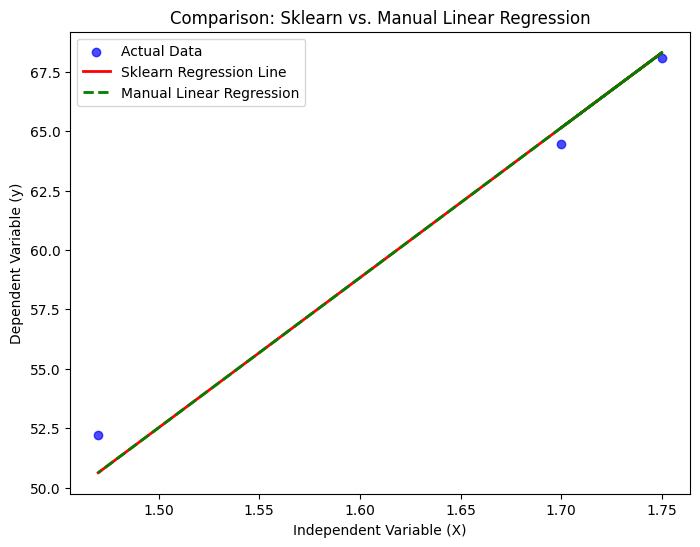

In [39]:
# Solution 2a.4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/linear_regression_dataset.csv")

# Assuming the dataset has two columns: 'X' (independent variable) and 'y' (dependent variable)
X = df.iloc[:, :-1].values  # Independent variable
y = df.iloc[:, -1].values   # Dependent variable

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------- Sklearn Linear Regression ----------------------
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)  # Train Model
y_pred_sklearn = lin_reg.predict(X_test)  # Predictions

# ---------------------- Manual Linear Regression (Normal Equation) ----------------------
# Add bias term (X0 = 1) for intercept
X_b_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_b_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Compute theta using the Normal Equation
theta_manual = np.linalg.inv(X_b_train.T.dot(X_b_train)).dot(X_b_train.T).dot(y_train)

# Predict values manually
y_pred_manual = X_b_test.dot(theta_manual)

# ---------------------- Plot Comparison ----------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label="Actual Data", alpha=0.7)

# Sklearn Regression Line
plt.plot(X_test, y_pred_sklearn, color='red', linewidth=2, label="Sklearn Regression Line")

# Manual Regression Line
plt.plot(X_test, y_pred_manual, color='green', linewidth=2, linestyle="dashed", label="Manual Linear Regression")

plt.xlabel("Independent Variable (X)")
plt.ylabel("Dependent Variable (y)")
plt.title("Comparison: Sklearn vs. Manual Linear Regression")
plt.legend()
plt.show()


**Question 2b** Logistic Regression Task
Use the “logistic_regression_dataset.csv”
1. Split the dataset into training set and test set in the ratio of 70:30 or 80:20
2. Train the logistic regression classifier (using inbuilt function: LogisticRegression from
sklearn).
3. Print the confusion matrix and accuracy.

**Question 2b.1** Split the dataset into training set and test set in the ratio of 70:30 or 80:20

In [40]:
# Solution 2b.1

import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/logistic_regression_dataset.csv")

# Assuming the last column is the target variable
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Target variable (Binary classification)

# ---------------- Split the data (Choose 70:30 or 80:20) ----------------
split_ratio = 0.3  # Change to 0.2 for 80:20 split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split_ratio, random_state=42)

# Print dataset shapes
print(f"Training set size: {X_train.shape}, {y_train.shape}")
print(f"Testing set size: {X_test.shape}, {y_test.shape}")
print(f"X Train : {X_train.shape}")
print(f"y Train : {y_train.shape}")
print(f"x Test : {X_test.shape}")
print(f"y Test : {y_test.shape}")


Training set size: (280, 4), (280,)
Testing set size: (120, 4), (120,)
X Train : (280, 4)
y Train : (280,)
x Test : (120, 4)
y Test : (120,)


**Question 2b.2** Train the logistic regression classifier (using inbuilt function: LogisticRegression from
sklearn).

In [41]:
# Solution 2b.2

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/logistic_regression_dataset.csv")

# Check for non-numeric columns
print("Columns with non-numeric data:\n", df.select_dtypes(include=['object']).columns)

# Convert categorical columns to numeric using Label Encoding
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Label Encoder for {col}: {le.classes_}")
    label_encoders[col] = le  # Store encoders if needed later for inverse transform

# Splitting dataset (70% train, 30% test)
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Make Predictions
y_pred = log_reg.predict(X_test)

# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")



Columns with non-numeric data:
 Index(['Gender'], dtype='object')
Label Encoder for Gender: ['Female' 'Male']
Model Accuracy: 0.85


**Question 2b.3** Print the confusion matrix and accuracy

In [42]:
# Solution 2b.3

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/logistic_regression_dataset.csv")

# Convert categorical columns to numeric using Label Encoding
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders if needed later

# Splitting dataset (70% train, 30% test)
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Make Predictions
y_pred = log_reg.predict(X_test)

# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print Results
print(f"Model Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)


Model Accuracy: 0.85

Confusion Matrix:
 [[71  2]
 [16 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89        73
           1       0.94      0.66      0.78        47

    accuracy                           0.85       120
   macro avg       0.88      0.82      0.83       120
weighted avg       0.86      0.85      0.84       120



**Question 3**: SVM

Use the dataset “Bank_Personal_Loan_Modelling.csv”

1. Store the dataset in your google drive and in Colab file load the dataset from your drive.
2. Check the shape and head of the dataset.
3. Age, Experience, Income, CCAvg, Mortgage, Securities are the features and Credit Card
is your Target Variable.
i. Take any 3 features from the six features given above
ii. Store features and targets into a separate variable
iii. Look for missing values in the data, if any, and address them accordingly.
iv. Plot a 3D scatter plot using Matplotlib.
4. Split the dataset into 80:20. (3 features and 1 target variable).
5. Train the model using scikit learn SVM API (LinearSVC) by setting the regularization
parameter C as C = {0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000}.
i. For each value of C Print the score on test data
ii. Make the prediction on test data
iii. Print confusion matrix and classification report
6. Use gridSearchCV a cross-validation technique to find the best regularization parameters (i.e.: the best value of C).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (5000, 14)

First 5 rows of dataset:
    ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0     

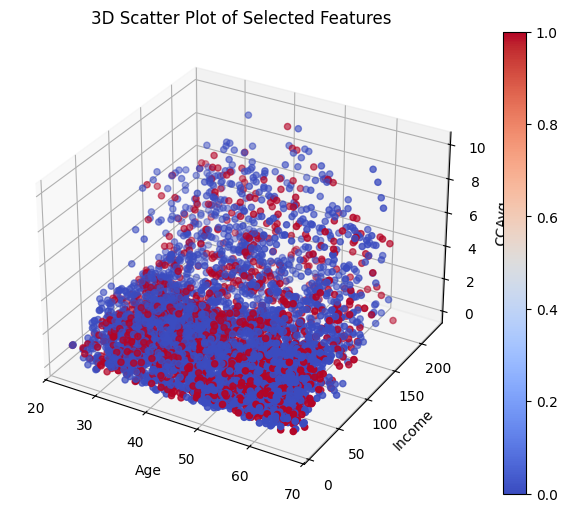

Correlation Matrix : 
                  Age  Experience    Income  CreditCard
Age         1.000000    0.994215 -0.055269    0.007681
Experience  0.994215    1.000000 -0.046574    0.008967
Income     -0.055269   -0.046574  1.000000   -0.002385
CreditCard  0.007681    0.008967 -0.002385    1.000000
Prediction on data: C Value: 0.0001

Prediction: [1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 1
 0 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 1 0 1
 0 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1
 1 1 1 1 1 1 0 1 0 1 1 0 0 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 1 1 1
 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 0 1 1 1 1 0 0 0 1 0 1 0
 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 1 1 0 0 0 0 0 1 1 0 1 1 0 1 1
 1 1 1 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0
 1 1 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 0 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 0 1 1 1 1 1 

In [43]:
# Solution 3

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from google.colab import drive

warnings.simplefilter("ignore")
#drive.flush_and_unmount()

# Solution 3.1: Load Dataset from Google Drive
# Load dataset
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Bank_Personal_Loan_Modelling.csv')

# Load dataset
# df = pd.read_csv(file_path)

# Solution 3.2: Check Dataset Shape & Head
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows of dataset:\n", df.head())

# Solution 3.3: Feature Selection & Missing Value Handling
# Select 3.3(i) features and target variable
selected_features = ['Age', 'Income', 'CCAvg']
target_variable = 'CreditCard'
# Solution 3.3(ii) Store features and target into separate variables
X = df[selected_features]
y = df[target_variable]

# Solution 3.3(iii)Check for missing values
print("\nMissing Values:\n", X.isnull().sum())

# If missing values exist, fill with median
X.fillna(X.median(), inplace=True)


# Solution 3.3(iv): Plot a 3D Scatter Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X['Age'], X['Income'], X['CCAvg'], c=y, cmap='coolwarm', marker='o')
ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("CCAvg")
ax.set_title("3D Scatter Plot of Selected Features")
plt.colorbar(scatter)
plt.show()

correlation = df[['Age', 'Experience', 'Income','CreditCard']].corr()
print("Correlation Matrix : \n", correlation)

# Solution 3.4:- Split Dataset into 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# StandardScaler() standardizes features by subtracting mean and scaling to unit variance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # Fit and transform training data
X_test = scaler.transform(X_test)         # Transform testing data

# Solution 3.5:- Train Linear SVM with Different C Values
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
for C in C_values:
    model = LinearSVC(C=C, class_weight='balanced', max_iter=10000, dual=False)
    model.fit(X_train, y_train)
    # Solution 3.5(ii):- Evaluate on test data
    y_pred = model.predict(X_test)
    print(f"Prediction on data: C Value: {C}\n")
    print(f"Prediction: {y_pred}")
    acc = accuracy_score(y_test, y_pred)
    score = model.score(X_test, y_test)
    # Solution 3.5(i)
    print(f"\nC={C} | Model Accuracy: {acc:.4f} | Model Score: {score}\n")
    # Solution 3.5(iii):- Print confusion matrix & classification report
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=1))

# Solution 3.6:-Use GridSearchCV for Best Regularization Parameter
param_grid = {'C': C_values}
grid_search = GridSearchCV(LinearSVC(class_weight ='balanced', max_iter=10000, dual=False), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_C = grid_search.best_params_['C']
print(f"\nBest C Value Found: {best_C}")
print(f"\nBest Cross Validation Score : {grid_search.best_score_:.4f}")



**Question 3:** SVM

In the report provide your findings for the output generated for all the kernels used and also describe the changes that happened after changing the regularization hyperparameter.

**Solution:-** Here, we are doing following steps:-


1.   We are defining Hyperparameters and Kernels and we are train SVC models with different Kernels with Regularization values.
2.   After that we are ploting different confusion matrix with different kernels and C values.
1.   Finally we are showing kernal comparison summary.

In [17]:
# Solution 3:- Compare Kernels and Report

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/Bank_Personal_Loan_Modelling.csv')

# Selecting features and target
features = ["Age", "Experience", "Income"]
target = "CreditCard"

X = df[features]
y = df[target]

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling for better SVM performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define kernels and hyperparameter ranges
kernels = ["linear", "rbf", "sigmoid", "poly"]
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = ["scale", "auto", 0.01, 0.1, 1]  # For RBF & Sigmoid
degree_values = [2, 3, 4]  # For Poly

# Store results for analysis
results = []

for kernel in kernels:
    for C in C_values:
        if kernel == "poly":
            for degree in degree_values:
                model = SVC(kernel=kernel, C=C, degree=degree, class_weight="balanced")
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                test_acc = accuracy_score(y_test, y_pred)
                results.append((kernel, C, degree, "-", test_acc))
        elif kernel in ["rbf", "sigmoid"]:
            for gamma in gamma_values:
                model = SVC(kernel=kernel, C=C, gamma=gamma, class_weight="balanced")
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                test_acc = accuracy_score(y_test, y_pred)
                results.append((kernel, C, "-", gamma, test_acc))
        else:
            model = SVC(kernel=kernel, C=C, class_weight="balanced")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            test_acc = accuracy_score(y_test, y_pred)
            results.append((kernel, C, "-", "-", test_acc))

# Convert results into DataFrame
results_df = pd.DataFrame(results, columns=["Kernel", "C", "Degree", "Gamma", "Test Accuracy"])

# Find the best performing kernel
best_result = results_df.loc[results_df["Test Accuracy"].idxmax()]
print("\nBest Model Parameters:")
print(best_result)

# Print full results
print("\nSummary of Kernel Performance:")
print(results_df.sort_values(by="Test Accuracy", ascending=False))

# Generate Findings
findings = []
for kernel in kernels:
    kernel_data = results_df[results_df["Kernel"] == kernel]
    best_row = kernel_data.loc[kernel_data["Test Accuracy"].idxmax()]
    findings.append(
        f"Kernel: {kernel} → Best C: {best_row['C']}, Degree: {best_row['Degree']}, Gamma: {best_row['Gamma']}, "
        f"Test Accuracy: {best_row['Test Accuracy']:.3f}"
    )

print("\nFindings Report:")
for finding in findings:
    print(finding)



Mounted at /content/drive
Missing values:
 ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Best Model Parameters:
Kernel           poly
C                0.01
Degree              4
Gamma               -
Test Accuracy    0.67
Name: 57, dtype: object

Summary of Kernel Performance:
     Kernel      C Degree  Gamma  Test Accuracy
57     poly   0.01      4      -          0.670
55     poly   0.01      2      -          0.666
60     poly   0.10      4      -          0.663
63     poly   1.00      4      -          0.662
66     poly  10.00      4      -          0.655
..      ...    ...    ...    ...            ...
31  sigmoid   0.01      -   auto          0.292
5       rbf   0.01      -  scale  

**Question 4:** Decision Tree and Random Forest

Load the IRIS dataset. The dataset consists of 150 samples of iris flowers, each belonging to one of three species (setosa, versicolor, or virginica). Each sample includes four features: sepal length, sepal width, petal length, and petal width.
1. Visualize the distribution of each feature and the class distribution.
2. Encode the categorical target variable (species) into numerical values.
3. Split the dataset into training and testing sets (use an appropriate ratio).
4. Decision Tree Model
i. Build a decision tree classifier using the training set.
ii. Visualize the resulting decision tree.
iii. Make predictions on the testing set and evaluate the model's performance using
appropriate metrics (e.g., accuracy, confusion matrix).
5. Random Forest Model
i. Build a random forest classifier using the training set.
ii. Tune the hyperparameters (e.g., number of trees, maximum depth) if necessary.
iii. Make predictions on the testing set and evaluate the model's performance using
appropriate metrics and compare it with the decision tree model.

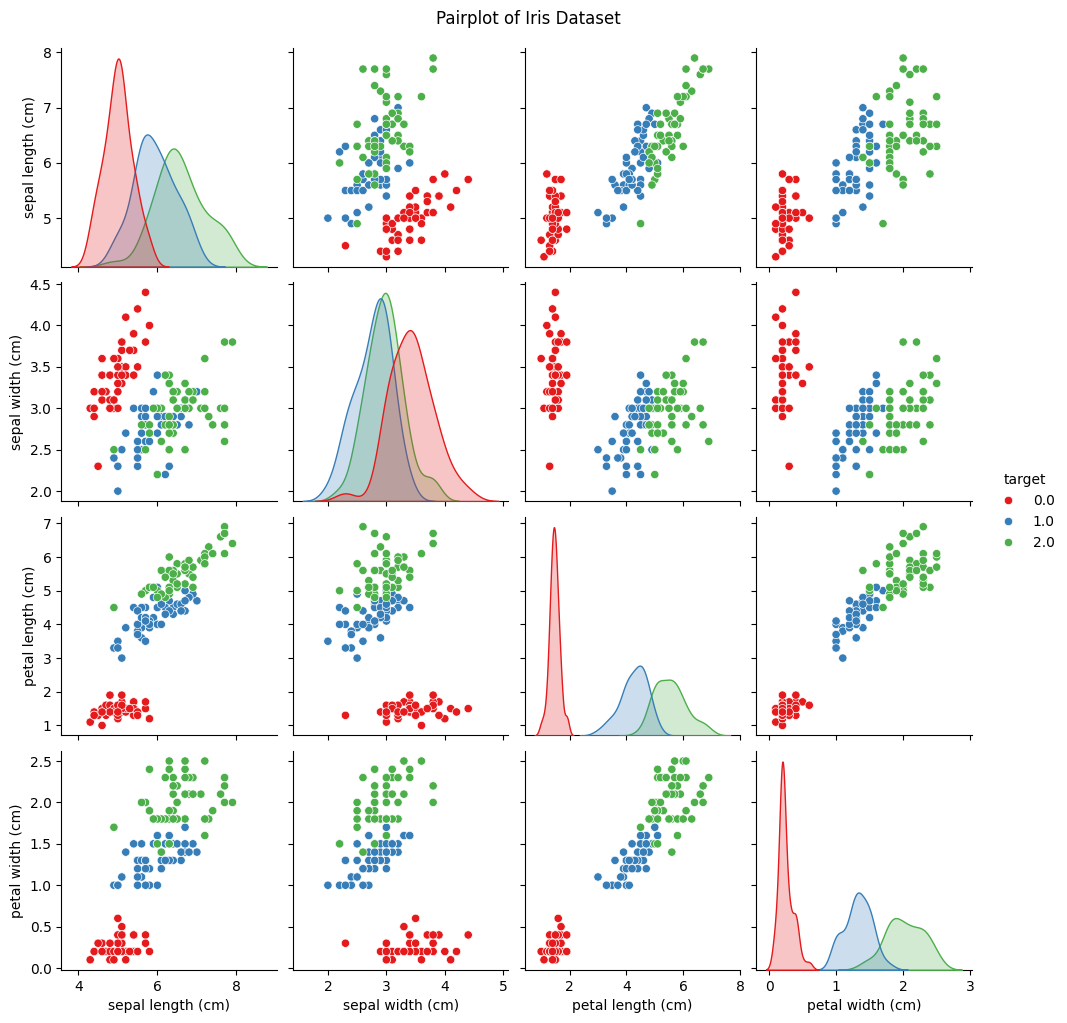

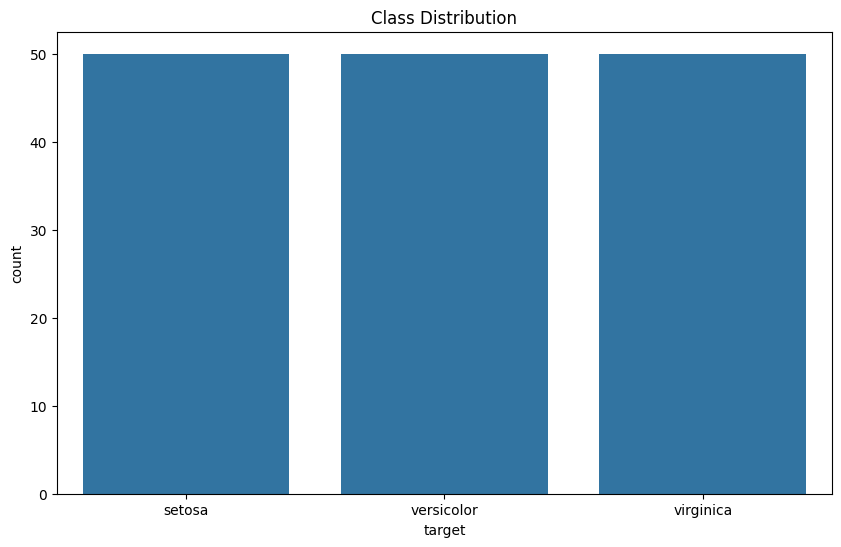

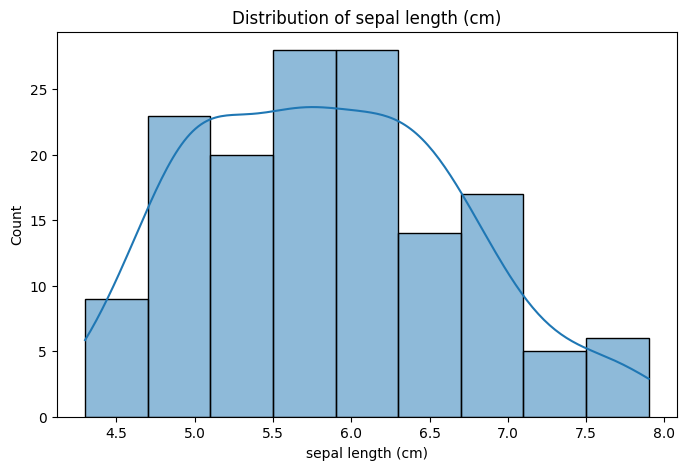

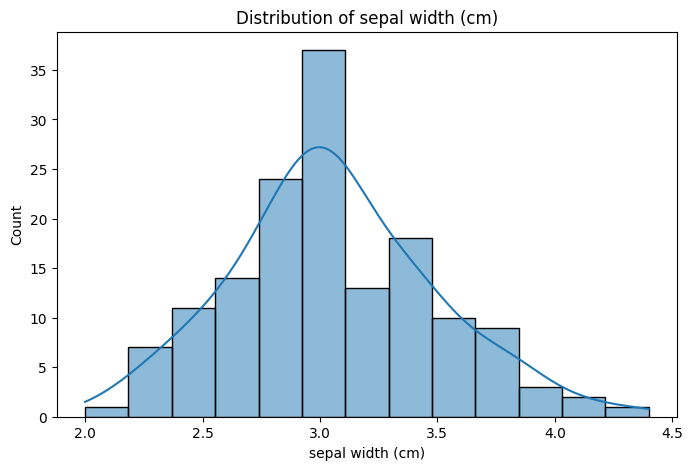

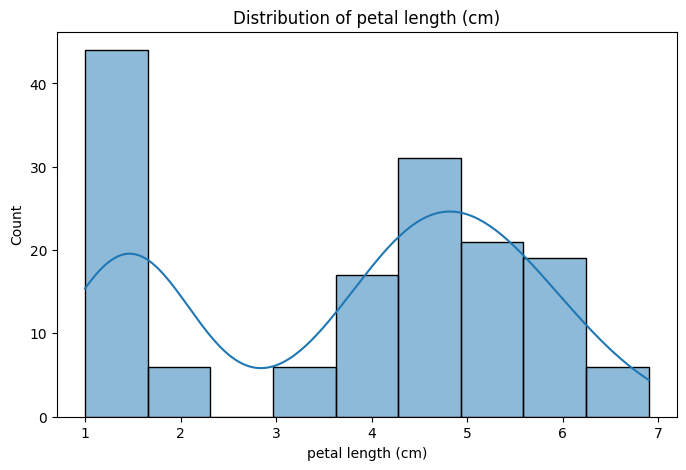

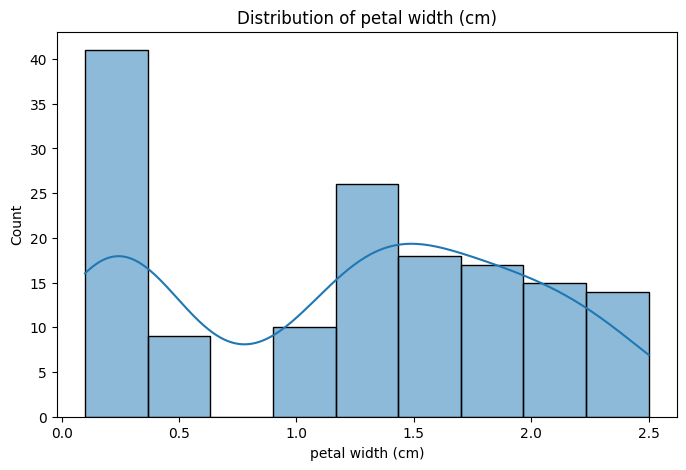

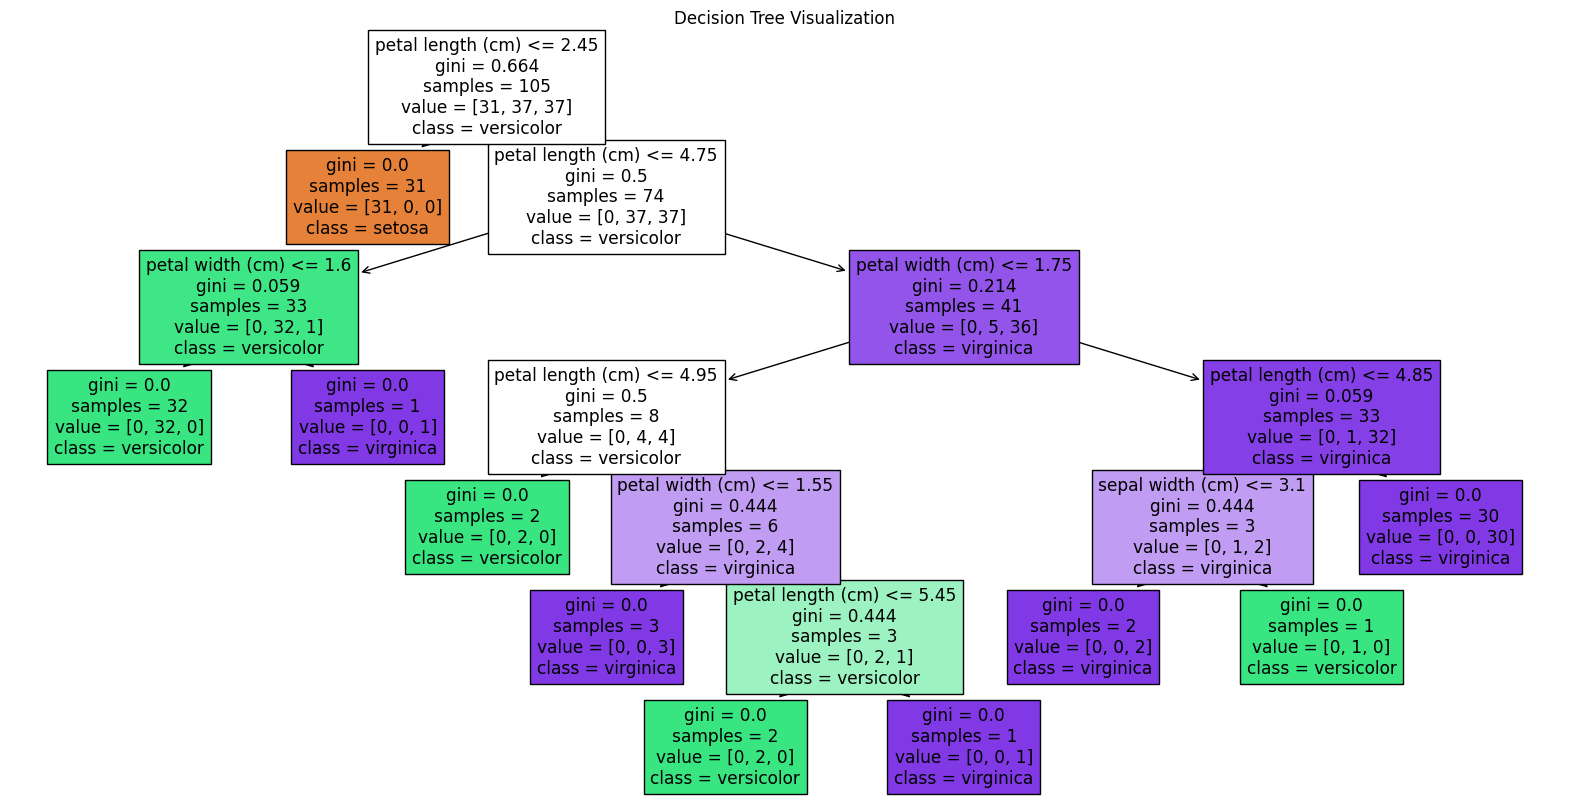

Decision Tree Accuracy: 1.0
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Decision Tree Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


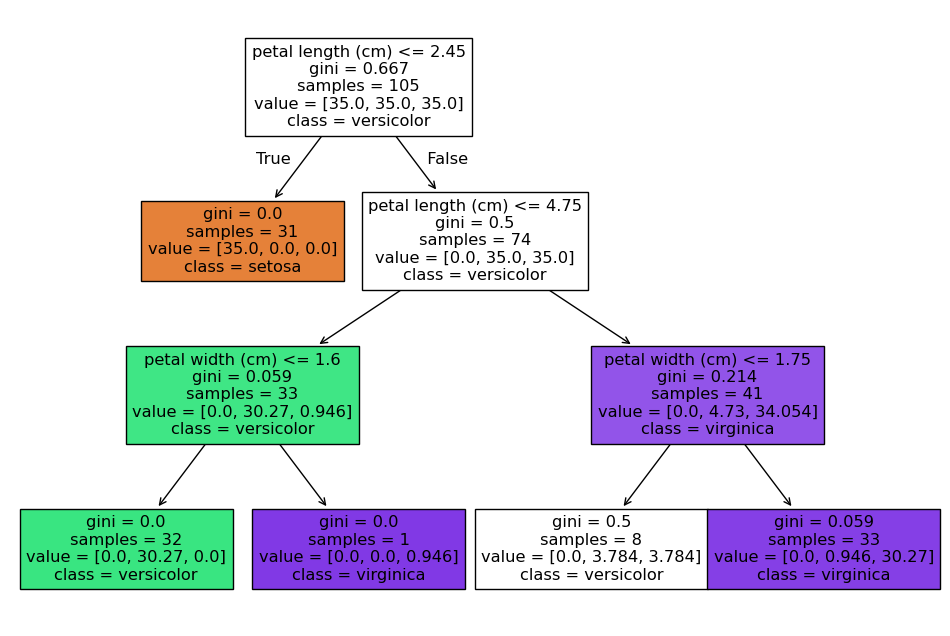


 Decision Tree Accuracy : 
 1.0

 Decision Tree Confusion Matrix : 
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

 Decision Tree Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


 Random Forest Accuracy : 
 1.0

 Random Forest Confusion Matrix : 
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

 Random Forest Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00      

In [44]:
# Solution 4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the IRIS dataset
iris = load_iris()
iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])

# Solution 4.1:- Visualize the distribution of each feature and the class distribution
sns.pairplot(iris_df, hue='target', palette='Set1')
plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=iris_df)
plt.title('Class Distribution')
plt.xticks(ticks=[0,1,2], labels=iris.target_names)
plt.show()

for feature in iris.feature_names:
    plt.figure(figsize=(8, 5))
    sns.histplot(iris_df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

# Solution 4.2:- Encode the categorical target variable (species) into numerical values
encoder = LabelEncoder()
iris_df['target'] = encoder.fit_transform(iris_df['target'])

# Solution 4.3:- Split the dataset into training and testing sets
X = iris_df.drop('target', axis=1)
y = iris_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Solution 4.4:- Decision Tree Model
# Solution 4.4(i):- Build a decision tree classifier using the training set
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Solution 4.4(ii):- Visualize the resulting decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title('Decision Tree Visualization')
plt.show()

# Solution 4.4(iii):- Make predictions on the testing set and evaluate the model's performance
dt_predictions = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f'Decision Tree Accuracy: {dt_accuracy}')
print('Decision Tree Classification Report:\n', classification_report(y_test, dt_predictions))
print('Decision Tree Confusion Matrix:\n', confusion_matrix(y_test, dt_predictions))


# 4.5 (i) Build Decision Tree, Visualize, make predictions and evaluate model's performance

dt_classifier = DecisionTreeClassifier(max_depth = 3, min_samples_split = 30, class_weight='balanced', random_state=42)
dt_classifier.fit(X_train,y_train)

plt.figure(figsize=(12,8))
plot_tree(dt_classifier, feature_names=iris.feature_names, class_names=iris.target_names, filled =True)
plt.show()

y_pred_dt     = dt_classifier.predict(X_test)
acc_score_dt  = accuracy_score(y_test, y_pred_dt)
cm_dt         = confusion_matrix(y_test, y_pred_dt)
class_rpt_dt  = classification_report(y_test, y_pred_dt)

print("\n Decision Tree Accuracy : \n", acc_score_dt)
print("\n Decision Tree Confusion Matrix : \n", cm_dt)
print("\n Decision Tree Classification Report : \n", class_rpt_dt)

# 4.5 (ii)Build Random Forest Model, Tune Hyper parameters, make predictions, evaluate model's performance and Compare with Decision Tree Model

rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=3, bootstrap = True, class_weight='balanced', random_state = 42)
rf_classifier.fit(X_train, y_train)

y_pred_rf     = rf_classifier.predict(X_test)
acc_score_rf  = accuracy_score(y_test, y_pred_rf)
cm_rf         = confusion_matrix(y_test, y_pred_rf)
class_rpt_rf  = classification_report(y_test, y_pred_rf)

print("\n Random Forest Accuracy : \n", acc_score_rf)
print("\n Random Forest Confusion Matrix : \n", cm_rf)
print("\n Random Forest Classification Report : \n", class_rpt_rf)

# 4.5(iii) Find optimal hyperparamters which shows best model's performance
param_grid = {
      'n_estimators': [10,12,15],
      'max_depth': [2,3,5],
      'min_samples_split': [30,35,40],
      'min_samples_leaf': [3,4,5]
            }

grid = GridSearchCV(estimator = rf_classifier, param_grid = param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Hyper Parameter using Grid Search CV : ", grid.best_params_)
print("Best Cross Validation Score : ", grid.best_score_)

if acc_score_rf > acc_score_dt:
    print("\nRandom Forest Classifier has performed better than Decision Tree Classifier.")
else:
    print("\nDecision Tree Classifier has performed better than Random Forest Classifier.")
